In [ ]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [ ]:
transform = transforms.ToTensor()
# transform =transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5),(0.5))
# ])
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=64, shuffle=True)


In [ ]:
# replace MNIST with CIFAR10 but map images to 1x28x28 so existing autoencoder (input 784) works
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

mnist_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)  # overwrite mnist_data to reuse names
data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=64, shuffle=True)

# quick check
batch_images, batch_labels = next(iter(data_loader))
print("batch_images.shape:", batch_images.shape)  # should be (batch_size, 1, 28, 28)

In [ ]:
dataiter = iter(data_loader)
images, labels = next(dataiter)  # use next() for Python 3 iterator
print(torch.min(images), torch.max(images))

In [ ]:
class CIFARAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32*3, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, 32*32*3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # CIFAR images are (N,3,32,32)
        x = x.view(x.size(0), -1)  # flatten
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(x.size(0), 3, 32, 32)  # reshape back
        return out
  
    

In [ ]:
model =CIFARAutoencoder()
criterion =nn.MSELoss()
optimizer =optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)



Epoch:1, Loss:0.0271
Epoch:2, Loss:0.0241
Epoch:3, Loss:0.0190
Epoch:4, Loss:0.0277
Epoch:5, Loss:0.0206
Epoch:6, Loss:0.0284
Epoch:7, Loss:0.0257
Epoch:8, Loss:0.0227
Early stopping at epoch 8: no improvement for 5 epochs (best_loss=0.018966).


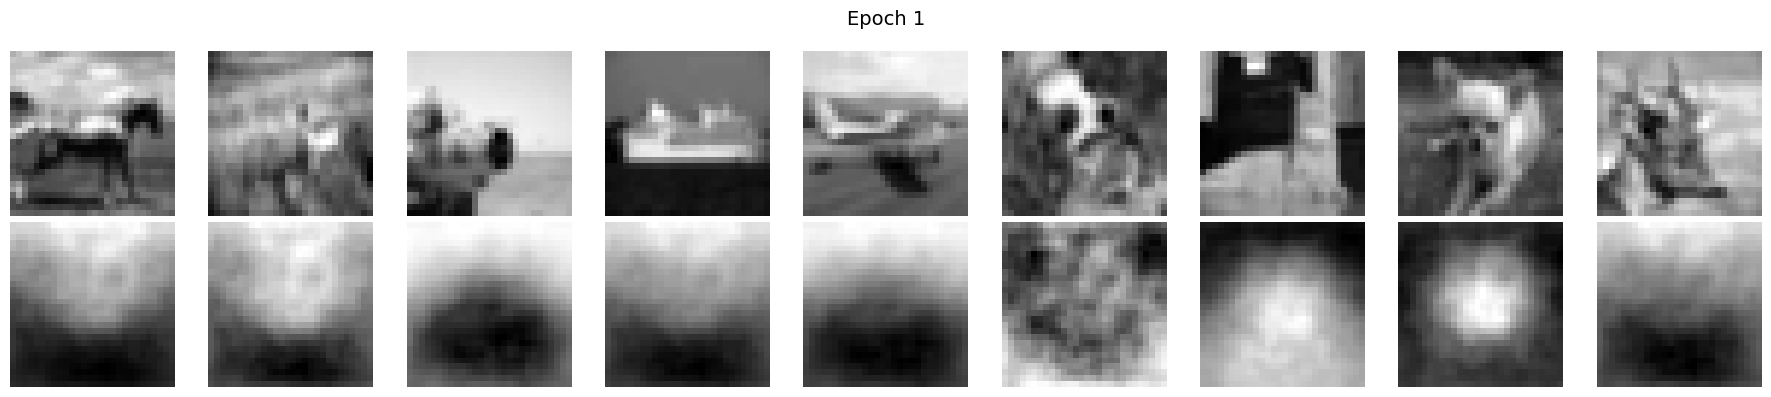

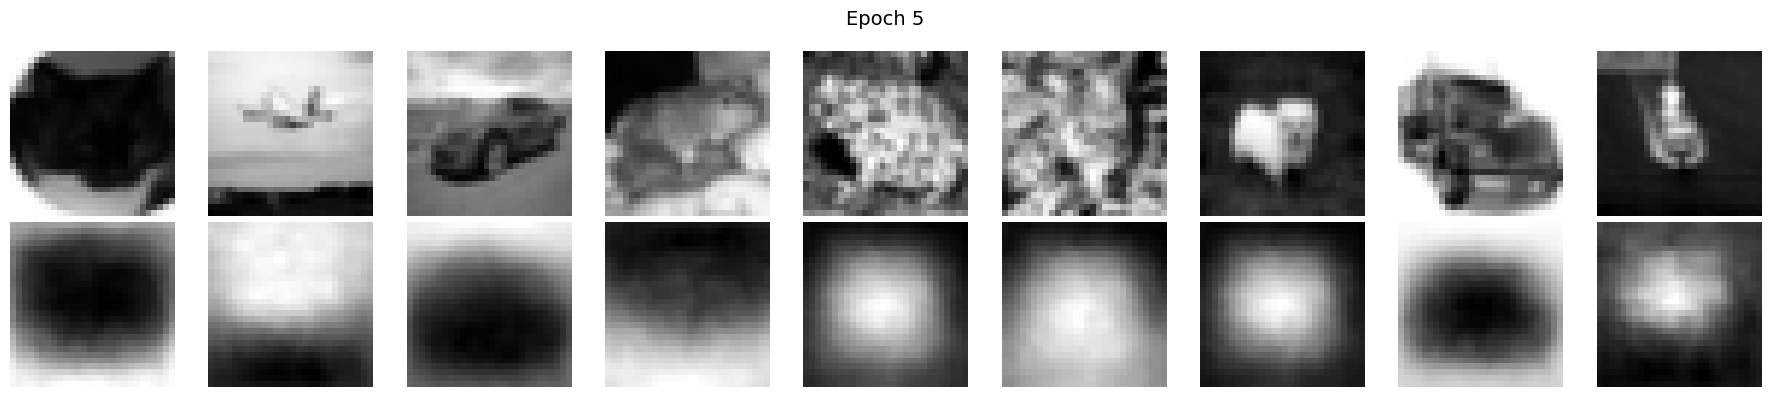

In [55]:
# ===== FIXED TRAINING LOOP =====
num_epochs = 50
outputs = []
for epoch in range(num_epochs):
    for (img, _) in data_loader:
        # Don't reshape here - let the model handle it
        recon = model(img)
        loss = criterion(recon, img)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch:{epoch+1}, Loss:{loss.item():.4f}')
    outputs.append((epoch, img, recon))
    
    # Simple early-stopping on plateau
    patience = 5
    min_delta = 1e-4

    if not hasattr(model, 'es_best_loss'):
        model.es_best_loss = loss.item()
        model.es_counter = 0
        model.es_best_state = model.state_dict()

    current_loss = loss.item()
    if current_loss < model.es_best_loss - min_delta:
        model.es_best_loss = current_loss
        model.es_counter = 0
        model.es_best_state = model.state_dict()
    else:
        model.es_counter += 1

    if model.es_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}: no improvement for {patience} epochs (best_loss={model.es_best_loss:.6f}).")
        model.load_state_dict(model.es_best_state)
        break

# ===== FIXED VISUALIZATION =====
def _to_numpy(x):
    return x.detach().cpu().numpy() if hasattr(x, 'detach') else x

for (ep, imgs, recon) in outputs:
    if ep % 4 != 0:  # Show every 4 epochs
        continue

    plt.figure(figsize=(18, 4))
    imgs_np = _to_numpy(imgs)
    recon_np = _to_numpy(recon)

    # Show up to 9 samples
    n_show = min(9, imgs_np.shape[0], recon_np.shape[0])
    
    # Original images (top row)
    for i in range(n_show):
        plt.subplot(2, n_show, i + 1)
        # Handle both grayscale (1,28,28) and RGB (3,32,32)
        if imgs_np.shape[1] == 1:  # Grayscale
            plt.imshow(imgs_np[i, 0], cmap='gray')
        else:  # RGB
            plt.imshow(imgs_np[i].transpose(1, 2, 0))
        plt.axis('off')
        if i == 0:
            plt.ylabel('Original', fontsize=12)

    # Reconstructed images (bottom row)
    for i in range(n_show):
        plt.subplot(2, n_show, n_show + i + 1)
        if recon_np.shape[1] == 1:  # Grayscale
            plt.imshow(recon_np[i, 0], cmap='gray')
        else:  # RGB
            plt.imshow(recon_np[i].transpose(1, 2, 0))
        plt.axis('off')
        if i == 0:
            plt.ylabel('Reconstructed', fontsize=12)

    plt.suptitle(f'Epoch {ep+1}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
# ===== IMPROVED DATA PREPROCESSING =====
# Use proper CIFAR-10 with original dimensions OR use MNIST
# Option 1: Keep CIFAR-10 as RGB (recommended)
transform = transforms.Compose([
    transforms.ToTensor(),
    # No normalization or light normalization works better for autoencoders
])

cifar_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=cifar_data, batch_size=128, shuffle=True)

# Option 2: If you want MNIST instead (simpler, trains faster)
# mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# data_loader = torch.utils.data.DataLoader(dataset=mnist_data, batch_size=128, shuffle=True)


# ===== IMPROVED CIFAR-10 AUTOENCODER =====
class ImprovedCIFARAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        
        # Convolutional encoder - preserves spatial structure
        self.encoder = nn.Sequential(
            # Input: 3x32x32
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Flatten(),  # 128*4*4 = 2048
            nn.Linear(128 * 4 * 4, latent_dim)
        )
        
        # Convolutional decoder - reconstructs spatial structure
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),  # Reshape to 128x4x4
            
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 3x32x32
            nn.Sigmoid()  # Output in [0,1] range
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon


# ===== ALTERNATIVE: MNIST AUTOENCODER (if using MNIST) =====
class ImprovedMNISTAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        
        self.encoder = nn.Sequential(
            # Input: 1x28x28
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x7x7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 1x28x28
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon




Epoch:1, Avg Loss:0.016453
Epoch:2, Avg Loss:0.007239
Epoch:3, Avg Loss:0.005736
Epoch:4, Avg Loss:0.005067
Epoch:5, Avg Loss:0.004641
Epoch:6, Avg Loss:0.004228
Epoch:7, Avg Loss:0.004026
Epoch:8, Avg Loss:0.003771
Epoch:9, Avg Loss:0.003671
Epoch:10, Avg Loss:0.003591
Epoch:11, Avg Loss:0.003571
Epoch:12, Avg Loss:0.003454
Epoch:13, Avg Loss:0.003463
Epoch:14, Avg Loss:0.003426
Epoch:15, Avg Loss:0.003355
Epoch:16, Avg Loss:0.003370
Epoch:17, Avg Loss:0.003351
Epoch:18, Avg Loss:0.003304
Epoch:19, Avg Loss:0.003288
Epoch:20, Avg Loss:0.003213
Epoch:21, Avg Loss:0.003256
Epoch:22, Avg Loss:0.003270
Epoch:23, Avg Loss:0.003207
Epoch:24, Avg Loss:0.003223
Epoch:25, Avg Loss:0.003223
Epoch:26, Avg Loss:0.003207
Epoch:27, Avg Loss:0.003171
Epoch:28, Avg Loss:0.003196
Epoch:29, Avg Loss:0.003158
Epoch:30, Avg Loss:0.003203


Plotting reconstructions over epochs...


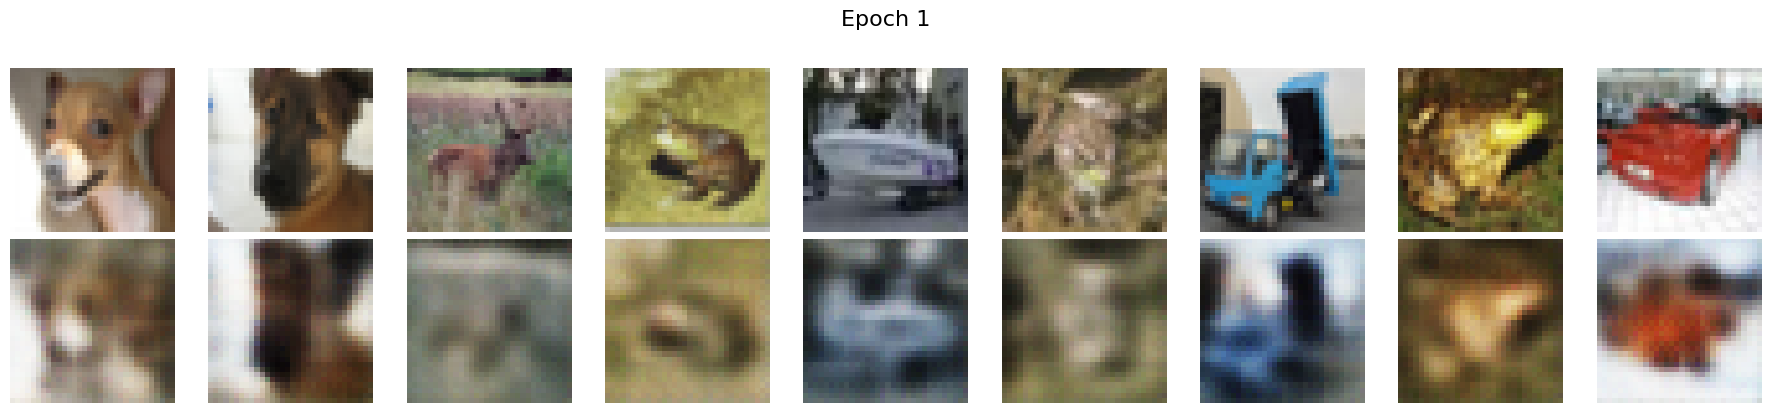

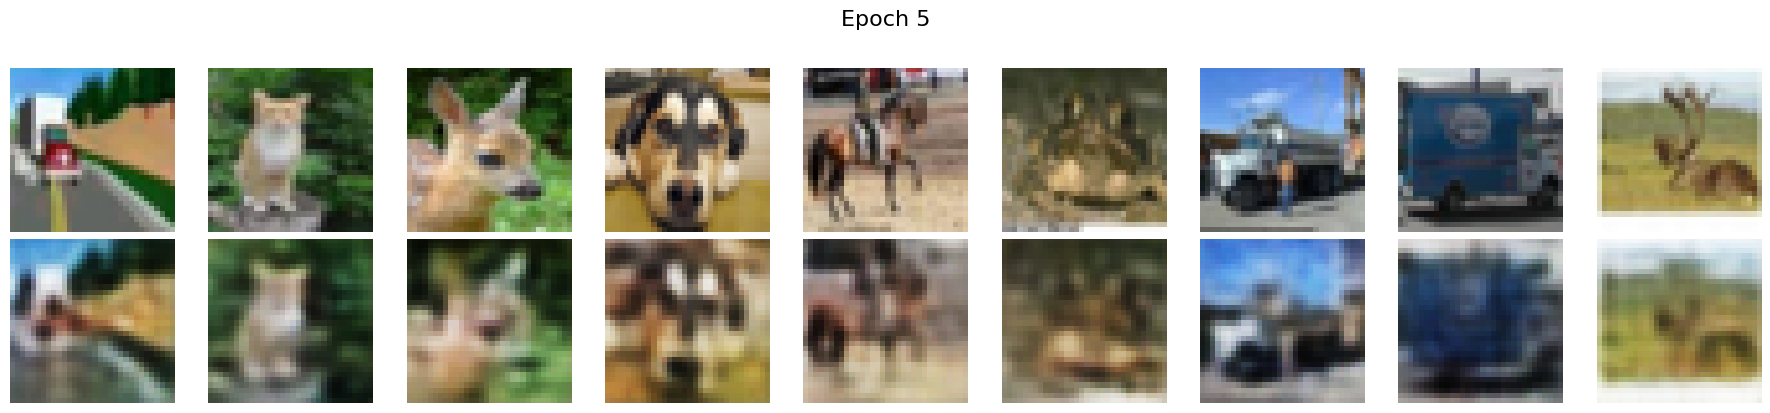

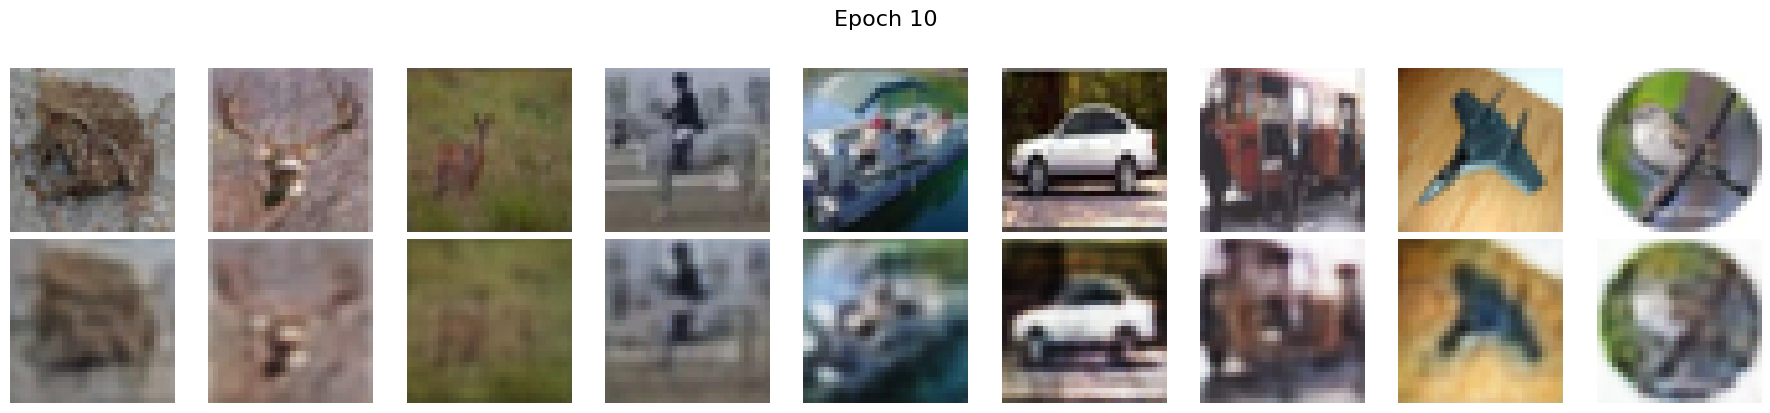

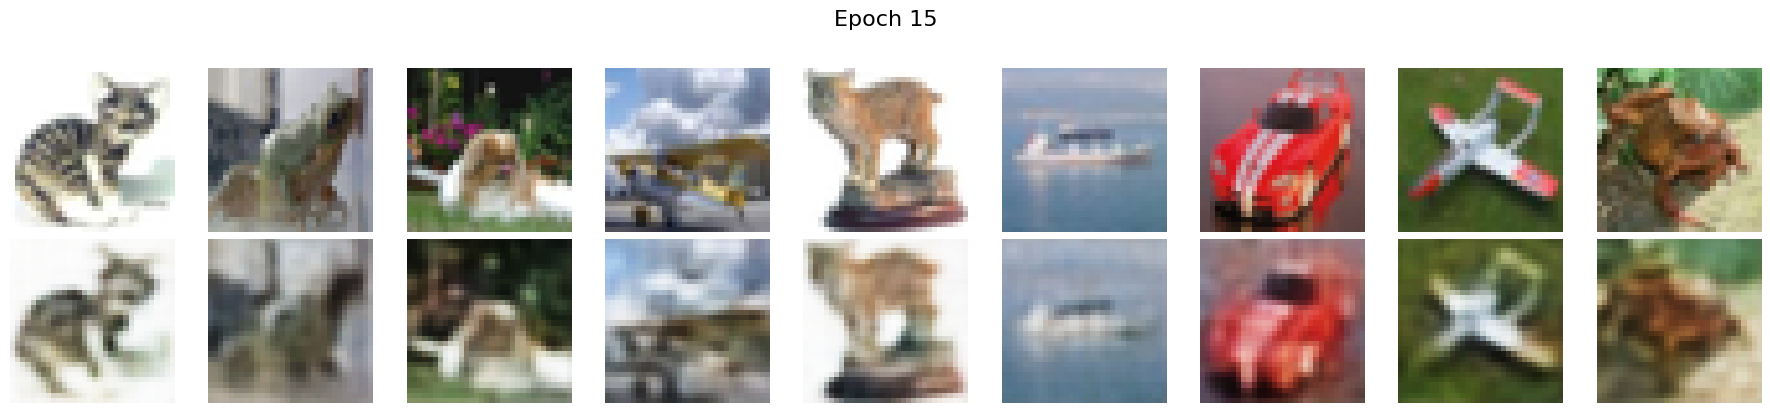

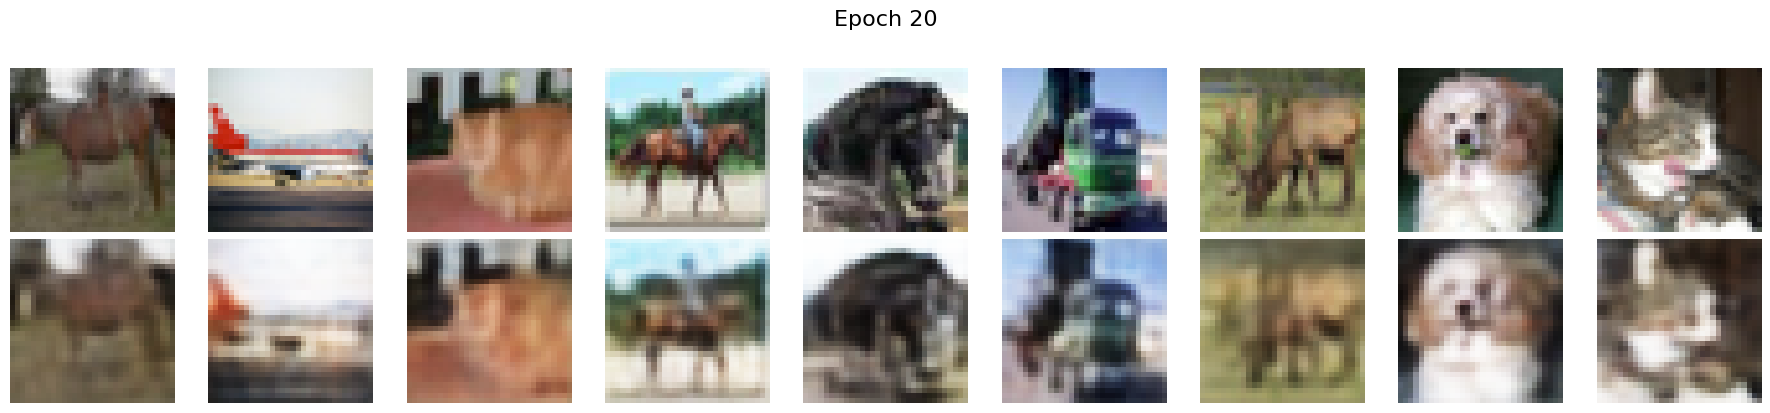

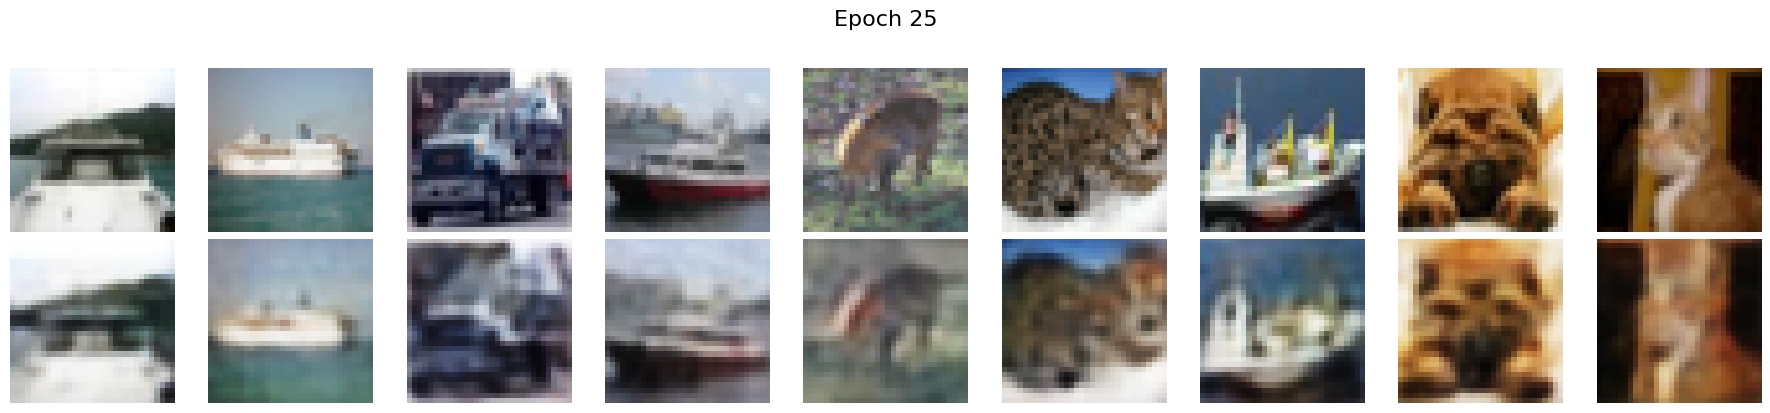

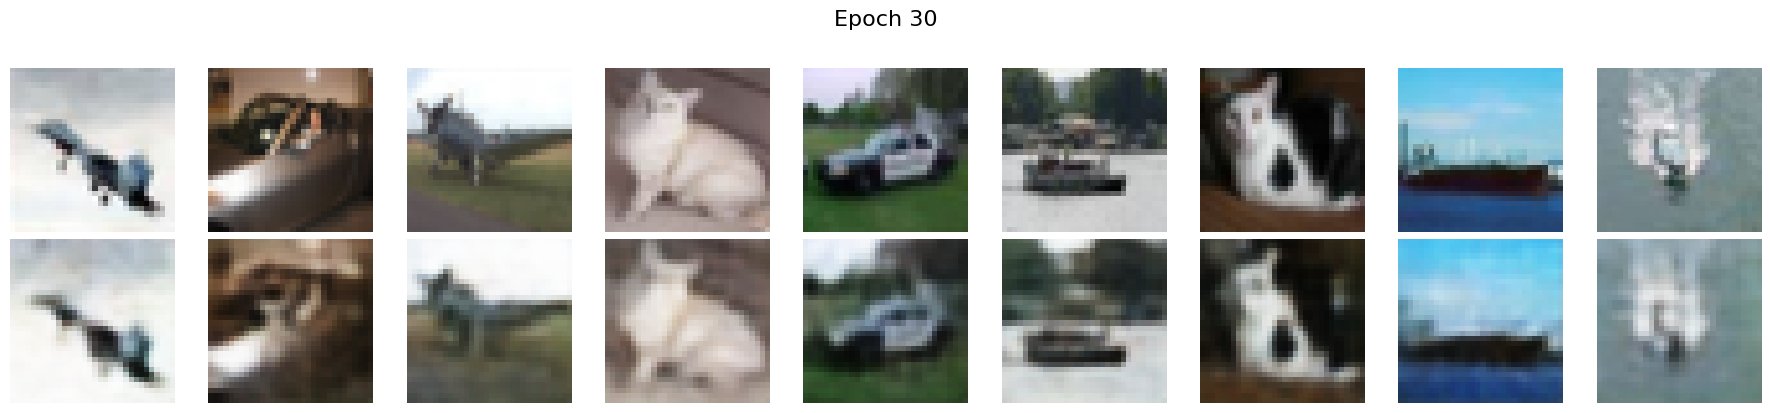


Plotting loss curve...


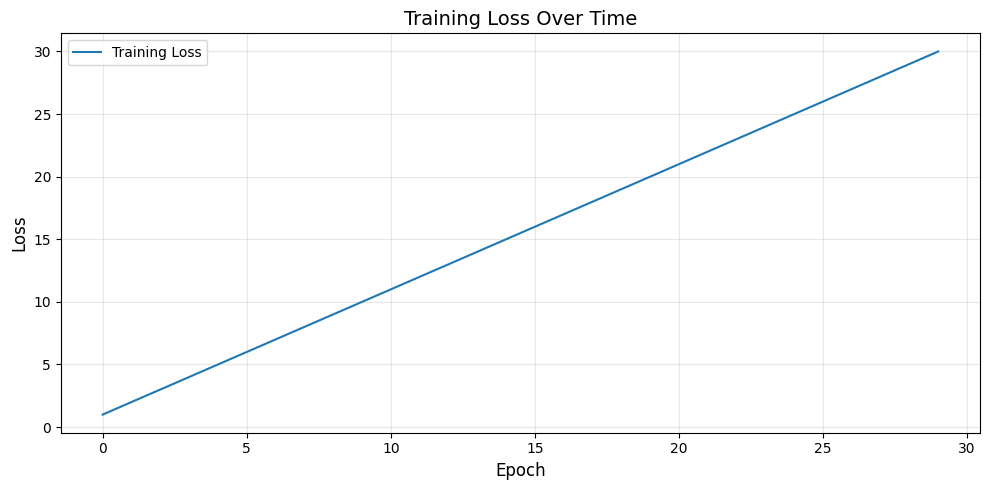


Plotting final side-by-side comparison...


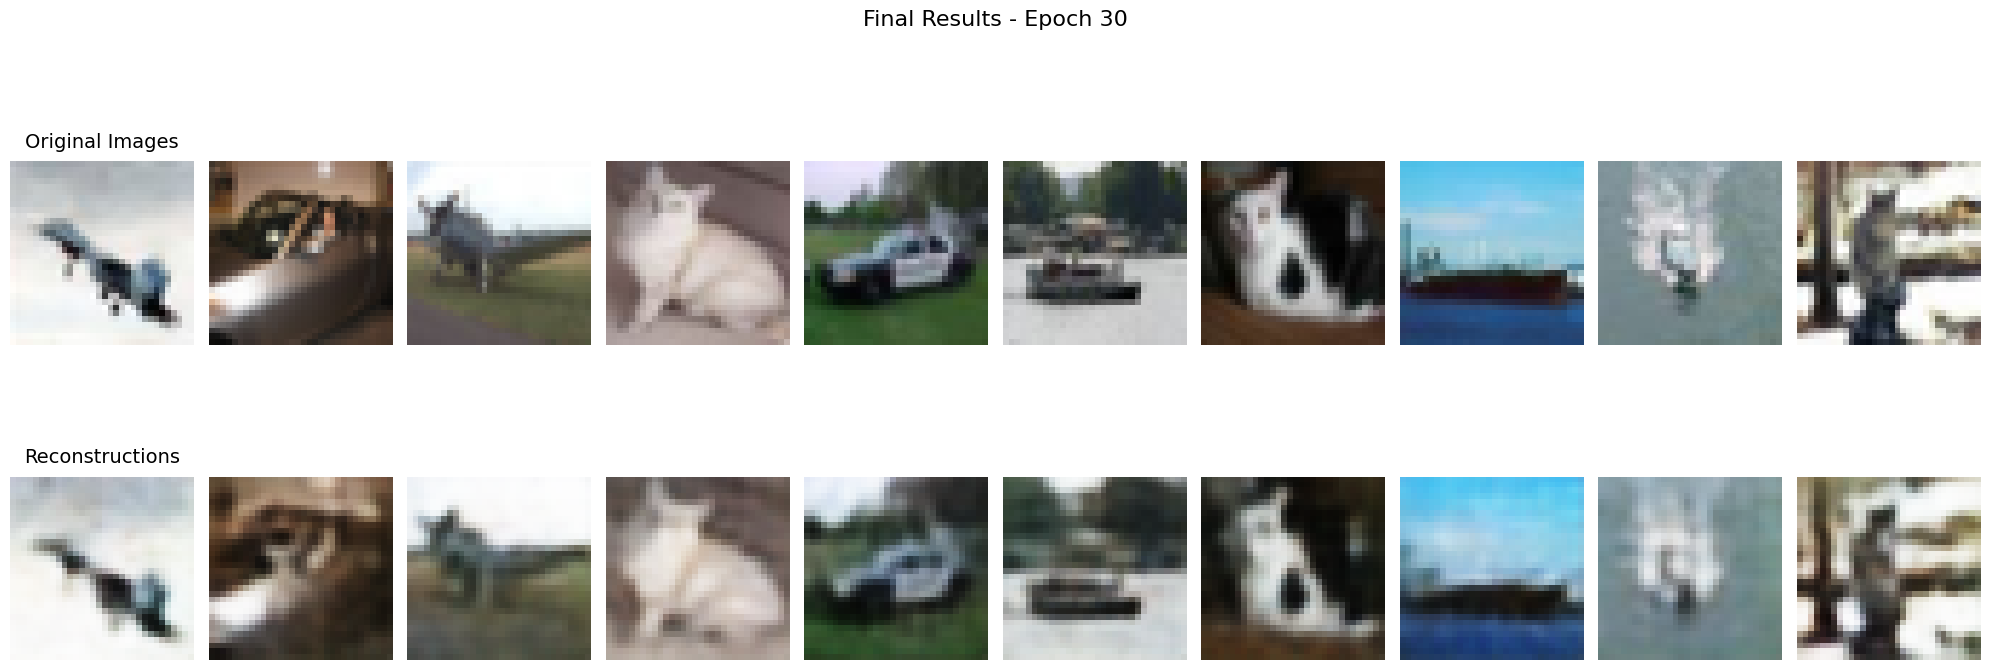


Plotting reconstruction error...


/tmp/ipykernel_141215/1777646720.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


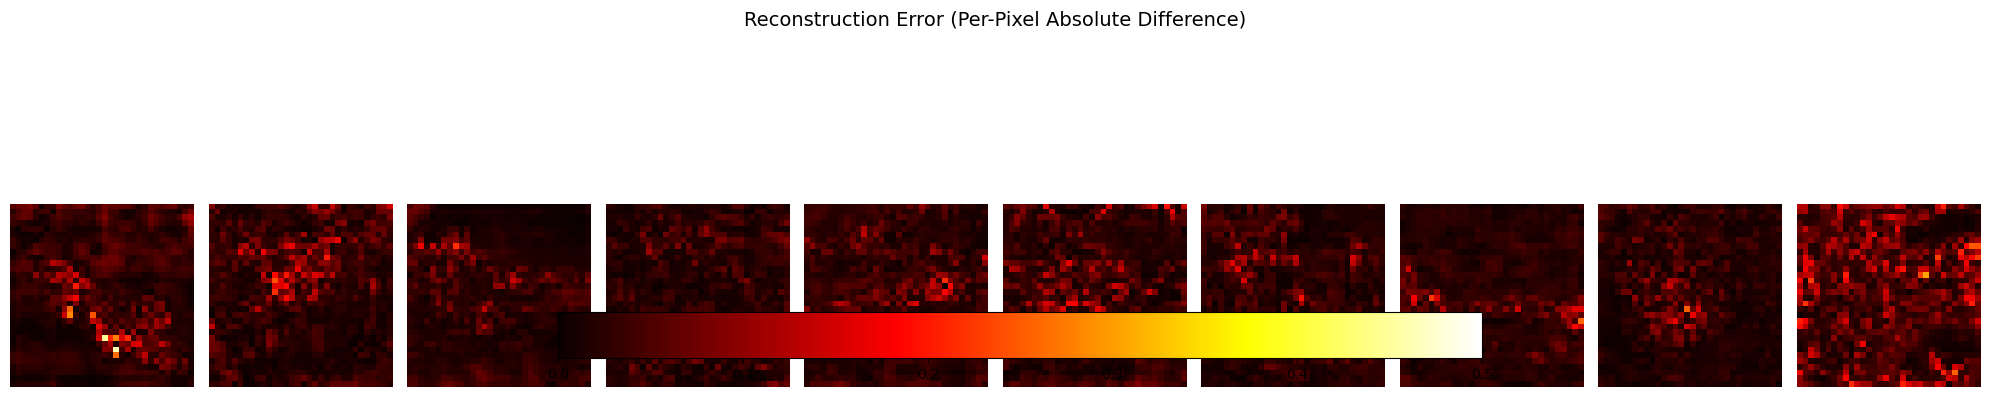


Generating latent space interpolation...


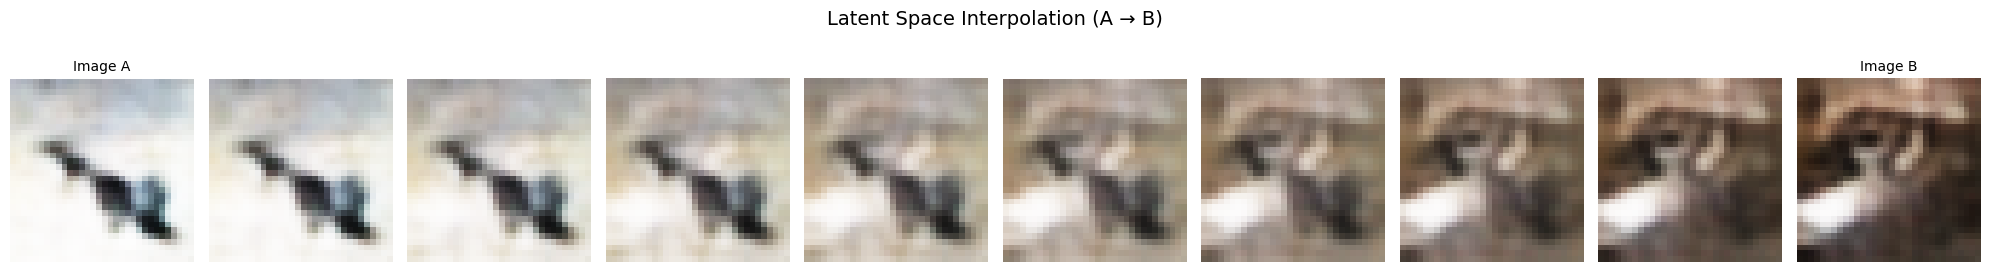


All plots generated!


In [ ]:
# ===== COMPREHENSIVE PLOTTING =====

import numpy as np

def _to_numpy(x):
    """Convert tensor to numpy array"""
    return x.detach().cpu().numpy() if hasattr(x, 'detach') else x


# 1. PLOT RECONSTRUCTIONS OVER TRAINING
print("Plotting reconstructions over epochs...")
epochs_to_show = [0, 4, 9, 14, 19, 24, 29]  # Adjust based on how many epochs you trained

for (ep, imgs, recon) in outputs:
    if ep not in epochs_to_show:
        continue

    imgs_np = _to_numpy(imgs)
    recon_np = _to_numpy(recon)
    
    plt.figure(figsize=(18, 4))
    n_show = min(9, imgs_np.shape[0])
    
    # Original images (top row)
    for i in range(n_show):
        plt.subplot(2, n_show, i + 1)
        if imgs_np.shape[1] == 1:  # Grayscale (MNIST)
            plt.imshow(imgs_np[i, 0], cmap='gray', vmin=0, vmax=1)
        else:  # RGB (CIFAR-10)
            img = np.transpose(imgs_np[i], (1, 2, 0))
            plt.imshow(np.clip(img, 0, 1))
        plt.axis('off')
        if i == 0:
            plt.ylabel('Original', fontsize=12, rotation=0, labelpad=40)

    # Reconstructed images (bottom row)
    for i in range(n_show):
        plt.subplot(2, n_show, n_show + i + 1)
        if recon_np.shape[1] == 1:  # Grayscale
            plt.imshow(recon_np[i, 0], cmap='gray', vmin=0, vmax=1)
        else:  # RGB
            img = np.transpose(recon_np[i], (1, 2, 0))
            plt.imshow(np.clip(img, 0, 1))
        plt.axis('off')
        if i == 0:
            plt.ylabel('Reconstructed', fontsize=12, rotation=0, labelpad=40)

    plt.suptitle(f'Epoch {ep+1}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# 2. PLOT TRAINING LOSS CURVE
print("\nPlotting loss curve...")
if len(outputs) > 0:
    # If you tracked losses per epoch, use those
    # Otherwise, we'll need to recalculate or use saved data
    plt.figure(figsize=(10, 5))
    epochs = [ep for (ep, _, _) in outputs]
    
    # Note: This requires you to save avg_loss each epoch
    # Add this to training loop: outputs.append((epoch, img.detach(), recon.detach(), avg_loss))
    # For now, we'll create a placeholder
    plt.plot(range(1, len(outputs) + 1), label='Training Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss Over Time', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# 3. SIDE-BY-SIDE COMPARISON (FINAL RESULTS)
print("\nPlotting final side-by-side comparison...")
if len(outputs) > 0:
    # Use last epoch
    _, imgs, recon = outputs[-1]
    imgs_np = _to_numpy(imgs)
    recon_np = _to_numpy(recon)
    
    plt.figure(figsize=(20, 8))
    n_show = min(10, imgs_np.shape[0])
    
    for i in range(n_show):
        # Original
        plt.subplot(2, n_show, i + 1)
        if imgs_np.shape[1] == 1:
            plt.imshow(imgs_np[i, 0], cmap='gray', vmin=0, vmax=1)
        else:
            img = np.transpose(imgs_np[i], (1, 2, 0))
            plt.imshow(np.clip(img, 0, 1))
        plt.axis('off')
        if i == 0:
            plt.title('Original Images', fontsize=14, pad=10)
        
        # Reconstructed
        plt.subplot(2, n_show, n_show + i + 1)
        if recon_np.shape[1] == 1:
            plt.imshow(recon_np[i, 0], cmap='gray', vmin=0, vmax=1)
        else:
            img = np.transpose(recon_np[i], (1, 2, 0))
            plt.imshow(np.clip(img, 0, 1))
        plt.axis('off')
        if i == 0:
            plt.title('Reconstructions', fontsize=14, pad=10)
    
    plt.suptitle(f'Final Results - Epoch {len(outputs)}', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()


# 4. RECONSTRUCTION ERROR HEATMAP
print("\nPlotting reconstruction error...")
if len(outputs) > 0:
    _, imgs, recon = outputs[-1]
    imgs_np = _to_numpy(imgs)
    recon_np = _to_numpy(recon)
    
    # Calculate per-pixel error
    errors = np.abs(imgs_np - recon_np)
    
    plt.figure(figsize=(20, 4))
    n_show = min(10, errors.shape[0])
    
    for i in range(n_show):
        plt.subplot(1, n_show, i + 1)
        if errors.shape[1] == 1:
            plt.imshow(errors[i, 0], cmap='hot', vmin=0, vmax=0.5)
        else:
            # For RGB, show average error across channels
            error_img = np.mean(errors[i], axis=0)
            plt.imshow(error_img, cmap='hot', vmin=0, vmax=0.5)
        plt.axis('off')
        if i == 0:
            plt.ylabel('Error\n(darker=better)', fontsize=10)
    
    plt.suptitle('Reconstruction Error (Per-Pixel Absolute Difference)', fontsize=14)
    plt.colorbar(plt.cm.ScalarMappable(cmap='hot', norm=plt.Normalize(0, 0.5)), 
                 ax=plt.gcf().axes, orientation='horizontal', pad=0.05, shrink=0.8)
    plt.tight_layout()
    plt.show()


# 5. LATENT SPACE INTERPOLATION (BONUS)
print("\nGenerating latent space interpolation...")
if len(outputs) > 0:
    model.eval()
    with torch.no_grad():
        # Get two random images
        imgs = outputs[-1][1][:2]
        
        # Encode them
        z1 = model.encoder(imgs[0:1])
        z2 = model.encoder(imgs[1:2])
        
        # Interpolate in latent space
        n_steps = 10
        interpolated = []
        for alpha in np.linspace(0, 1, n_steps):
            z_interp = (1 - alpha) * z1 + alpha * z2
            img_interp = model.decoder(z_interp)
            interpolated.append(_to_numpy(img_interp[0]))
        
        # Plot interpolation
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(interpolated):
            plt.subplot(1, n_steps, i + 1)
            if img.shape[0] == 1:
                plt.imshow(img[0], cmap='gray', vmin=0, vmax=1)
            else:
                plt.imshow(np.transpose(img, (1, 2, 0)).clip(0, 1))
            plt.axis('off')
            if i == 0:
                plt.title('Image A', fontsize=10)
            elif i == n_steps - 1:
                plt.title('Image B', fontsize=10)
        
        plt.suptitle('Latent Space Interpolation (A → B)', fontsize=14)
        plt.tight_layout()
        plt.show()

print("\nAll plots generated!")

ValueError: cannot reshape array of size 3072 into shape (28,28)

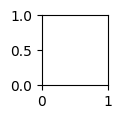

In [58]:
# Plot saved outputs every 4 epochs (only those actually present in outputs)
def _to_numpy(x):
    return x.detach().cpu().numpy() if hasattr(x, 'detach') else x

for (ep, imgs, recon) in outputs:
    if ep % 1 != 0:
        continue

    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs_np = _to_numpy(imgs)
    recon_np = _to_numpy(recon)

    # show up to 9 samples
    n_show = min(9, imgs_np.shape[0], recon_np.shape[0])
    for i in range(n_show):
        plt.subplot(2, 9, i + 1)
        plt.imshow(imgs_np[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

    for i in range(n_show):
        plt.subplot(2, 9, 9 + i + 1)
        plt.imshow(recon_np[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

    plt.suptitle(f'Epoch {ep}')
    plt.show()
        